In [1]:
import sys
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import numpy as np

import sys
# sys.path.insert(1, 'CDIP/')
from CDIPutils import magnitude, SQUIDify
import FourierUtils
from importlib import reload

import torch
from TorchUnet import UNet, HPOUNet

import cv2

import tensorflow as tf

2026-09-02 19:37:34.771048: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-02 19:37:34.837727: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-02 19:37:36.180205: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# 64p 50um
## Input image

/tmp/ipykernel_541898/32903851.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  SQUIDInputData = np.array(SQUIDify(rawInData, 62, 0)).swapaxes(1,3)
/tmp/ipykernel_541898/32903851.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  noise = np.array(torch.normal(mean=normInData.mean(), std=noise, size=np.shape(normInData)))


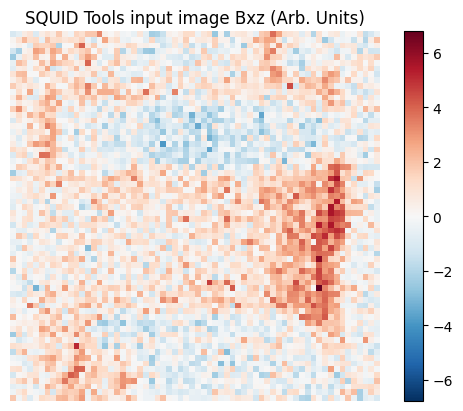

In [2]:
# rawInData = np.load("MAGIC_UNET/Data/OutOfDistribution/OutOfDistVal_64x64_50um_Bxyz.npy")
# rawInData = rawInData[:, :, :, 0:3]

def inputImage(fileNum, imNum, noise, filename=None):
    if filename == None:
        rawInData = np.load("/data/s4451856/training_data/64x64_SQUID_B_"+str(fileNum).zfill(3)+".npy")
        normInData = (rawInData - rawInData.mean()) / rawInData.std()
        normInData = np.flip(normInData, axis=2).swapaxes(1, 2)
    else:
        rawInData = np.load(filename)
        rawInData = rawInData.swapaxes(1,3)
        SQUIDInputData = np.array(SQUIDify(rawInData, 62, 0)).swapaxes(1,3)
        normInData = (SQUIDInputData - SQUIDInputData.mean()) / SQUIDInputData.std()

    noise = np.array(torch.normal(mean=normInData.mean(), std=noise, size=np.shape(normInData)))
    noisyData = normInData + noise

    # normInData = (rawInData - rawInData.mean()) / rawInData.std()

    normInputImage = noisyData[imNum]

    magMax = np.max(np.abs(normInputImage))
    plt.imshow(normInputImage, norm="linear", cmap="RdBu_r",
                        vmin=-magMax, vmax=magMax)
    plt.axis("off")
    plt.colorbar()
    plt.title("SQUID Tools input image Bxz (Arb. Units)")
    plt.show()

    return normInputImage, normInData, rawInData

normInputImage, normInData, rawInData = inputImage(0, 0, 1, filename="/data/s4451856/training_data/64x64_50um_Bxyz_000.npy")

### Components

(1024, 64, 64, 1)


IndexError: index 1 is out of bounds for axis 2 with size 1

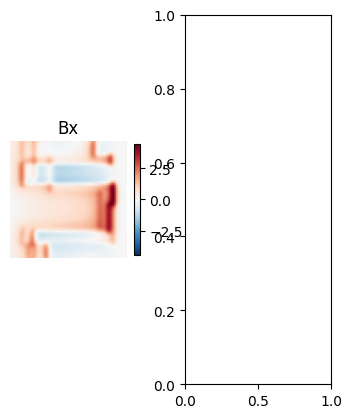

In [ ]:
def BIndiComp(inputImage):
    plt.subplot(1, 3, 1)
    x = inputImage[:, :, 0]
    xMax = np.max(np.abs(x))
    plt.imshow(x, norm="linear", cmap="RdBu_r",
            vmin=-xMax, vmax=xMax)
    plt.axis("off")
    plt.title("Bx")
    plt.colorbar(shrink=0.3)

    plt.subplot(1, 3, 2)
    y = inputImage[:, :, 1]
    yMax = np.max(np.abs(y))
    plt.imshow(y, norm="linear", cmap="RdBu_r",
            vmin=-yMax, vmax=yMax)
    plt.colorbar(shrink=0.3)
    plt.axis("off")
    plt.title("By")

    plt.subplot(1, 3, 3)
    z = inputImage[:, :, 2]
    zMax = np.max(np.abs(z))
    plt.imshow(z, norm="linear", cmap="RdBu_r",
            vmin=-zMax, vmax=zMax)
    plt.axis("off")
    plt.colorbar(shrink=0.3)
    plt.title("Bz")
    plt.show()

# normInData = (rawInData - rawInData.mean()) / rawInData.std()
# print(normInData.shape)
BIndiComp(normInData[0])

## Label image

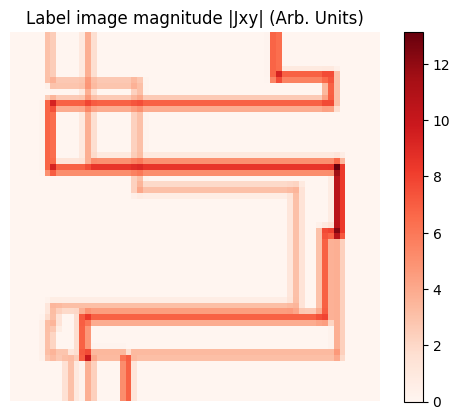

In [13]:
# rawOutData = np.load("MAGIC_UNET/Data/OutOfDistribution/OutOfDistVal_64x64_50um_Jxy.npy")

def labelImage(fileNum, imNum, filename=None):
    if filename == None:
        rawOutData = np.load("/data/s4451856/training_data/64x64_50um_Jxy_"+str(fileNum).zfill(3)+".npy")
    else:
        rawOutData = np.load(filename)

    normOutData = (rawOutData - rawOutData.mean()) / rawOutData.std()
    magOutImage = magnitude(normOutData[imNum])

    magMax = np.max(np.abs(magOutImage))
    plt.imshow(magOutImage, norm="linear", cmap="Reds",
                        vmin=0, vmax=magMax)
    plt.axis("off")
    plt.colorbar()
    plt.title("Label image magnitude |Jxy| (Arb. Units)")
    plt.show()

    return magOutImage

magOutImage = labelImage(0, 0, filename="/data/s4451856/training_data/64x64_50um_Jxy_000.npy")

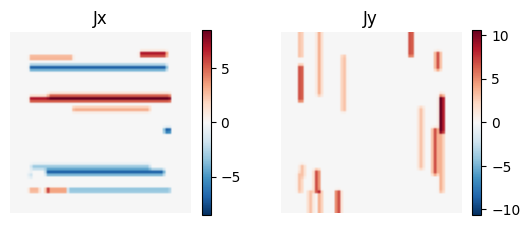

In [56]:
def JIndiComp(inputImage):
    plt.subplot(1, 2, 1)
    x = inputImage[:, :, 0]
    xMax = np.max(np.abs(x))
    plt.imshow(x, norm="linear", cmap="RdBu_r",
            vmin=-xMax, vmax=xMax)
    plt.axis("off")
    plt.title("Jx")
    plt.colorbar(shrink=0.5)

    plt.subplot(1, 2, 2)
    y = inputImage[:, :, 1]
    yMax = np.max(np.abs(y))
    plt.imshow(y, norm="linear", cmap="RdBu_r",
            vmin=-yMax, vmax=yMax)
    plt.colorbar(shrink=0.5)
    plt.axis("off")
    plt.title("Jy")

rawInData = np.load("/data/s4451856/training_data/64x64_50um_Jxy_000.npy")
rawInData = (rawInData - rawInData.mean()) / rawInData.std()
JIndiComp(rawInData[0])

## CDIP

In [155]:
class config(object):
    im_h = 64
    in_im_c = 1
    out_im_c = 2
    avgPool = True

    seed = 42
    layers = [64, 128, 256, 512]


model = HPOUNet(config)
model.load_state_dict(torch.load("models/CDIP_SQUID_B_noise/model.pt", weights_only=True))
model.eval()

HPOUNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (downLayers): ModuleList(
    (0): Down(
      (maxpool_conv): Sequential(
        (0): AvgPool2d(kernel_size=2, stride=2, padding=0)
        (1): DoubleConv(
          (double_conv): Sequential(
            (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
            (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

In [61]:
def predict(normInData):
    SQUIDInputTensor = torch.from_numpy(normInData.swapaxes(1,3).astype('float32'))

    with torch.inference_mode():
        predData = model(SQUIDInputTensor)
        predData = predData.detach().numpy().swapaxes(1,3)

    #predData = np.flip(predData, axis=2).swapaxes(1, 2)
    return predData

predData = predict(normInData)

## MAGIC UNET

In [8]:
model = tf.keras.layers.TFSMLayer("../MAGIC_UNET/MAGIC_UNet_64x64_50um/checkpoint/", call_endpoint="serving_default")

I0000 00:00:1788370769.901275  541898 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16035 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:3b:00.0, compute capability: 8.6
I0000 00:00:1788370769.903133  541898 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 16851 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:af:00.0, compute capability: 8.6


In [9]:
def UNET_normalized_inference(data_in_temp, model):
    
    # Calculate vector norms
    vect_norm = np.array(data_in_temp[:, :, :, 0]**2 +
                 data_in_temp[:, :, :, 1]**2 +
                 data_in_temp[:, :, :, 2]**2)**0.5
    vect_norm = np.max(vect_norm, axis=1)
    vect_norm = np.max(vect_norm, axis=1)

    file_size = np.size(vect_norm)
    for j in range(file_size):
        if vect_norm[j] != 0:
            data_in_temp[j, :, :, :] = data_in_temp[j, :, :, :] / vect_norm[j]

    # Make predictions
    predData = model(data_in_temp)#["conv2d_101"]
    data_out_temp = np.zeros([file_size, 64, 64, 2])

    for j in range(file_size):
        if vect_norm[j] != 0:
            data_out_temp[j, :, :, 0] = predData["conv2d_90"][j, :, :, 0] * vect_norm[j] * 1e11
            data_out_temp[j, :, :, 1] = predData["conv2d_101"][j, :, :, 0]* vect_norm[j] * 1e11
    return data_out_temp

In [10]:
predData = UNET_normalized_inference(rawInData.swapaxes(1,3), model)

2026-09-02 19:39:35.108059: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


## Fourier Analysis

In [4]:
reload(FourierUtils)
fft = FourierUtils.FFT(normInData)

In [ ]:
# bx_fourier_shifted, by_fourier_shifted, bz_fourier_shifted=dotheFFTsShift(normInData)
# bx_fourier_shifted_blurred, by_fourier_shifted_blurred, bz_fourier_shifted_blurred = blurBs(bx_fourier_shifted, by_fourier_shifted, bz_fourier_shifted, gauss_filt_strength)

# jx_fourier, jy_fourier = fourierj_from_fourierb(bx_fourier_shifted_blurred, by_fourier_shifted_blurred, bz_fourier_shifted_blurred)
# Jx_simulated, Jy_simulated = dotheiFFTsJShift([jx_fourier, jy_fourier])

# data_out_fourier=np.zeros([asize,pixel_number_x,pixel_number_x,2])
# data_out_fourier[:,:,:,0]=np.real(Jx_simulated)
# data_out_fourier[:,:,:,1]=np.real(Jy_simulated)
# J_mag_fourier=np.sqrt(data_out_fourier[:,:,:,0]**2+data_out_fourier[:,:,:,1]**2)

def Fourier(normInData):
    b_fourier_shifted=fft.dotheFFTsShift(normInData)
    b_fourier_shifted_blurred = fft.blurBs(b_fourier_shifted, fft.gauss_filt_strength)

    jx_fourier, jy_fourier = fft.fourierj_from_fourierb(b_fourier_shifted_blurred) # bx_fourier_shifted_blurred, by_fourier_shifted_blurred, bz_fourier_shifted_blurred)
    Jx_simulated, Jy_simulated = fft.dotheiFFTsJShift([jx_fourier, jy_fourier])

    data_out_fourier=np.zeros([fft.asize, fft.pixel_number_x, fft.pixel_number_x,2])
    data_out_fourier[:,:,:,0]=np.real(Jx_simulated)
    data_out_fourier[:,:,:,1]=np.real(Jy_simulated)
    # magPredData=np.sqrt(data_out_fourier[:,:,:,0]**2+data_out_fourier[:,:,:,1]**2)
    return data_out_fourier

predData = Fourier(normInData)
#predImage = predData[0]

### Magnitude Prediction

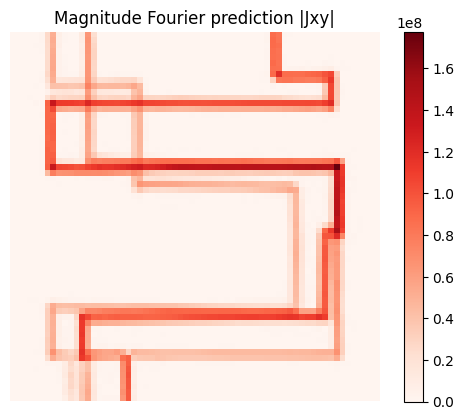

In [11]:
def magImage(image):
    magMax = np.max(np.abs(image))
    plt.imshow(image, norm="linear", cmap="Reds",
            vmin=0, vmax=magMax)
    plt.axis("off")
    plt.colorbar()
    plt.title("Magnitude Fourier prediction |Jxy|")
    plt.show()

magPredImage = magnitude(predData[0])
magImage(magPredImage)

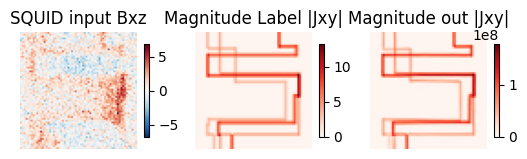

In [16]:
def inputLabelMagCompImage(inputImage, magOutImage, magPredImage):
    plt.subplot(1, 3, 1)
    inMax = np.max(np.abs(inputImage))
    plt.imshow(inputImage, norm="linear", cmap="RdBu_r",
            vmin=-inMax, vmax=inMax)
    plt.axis("off")
    plt.title("SQUID input Bxz")
    # plt.subplot(1, 6, 2)
    plt.colorbar(shrink=0.25)

    plt.subplot(1, 3, 2)
    outMax = np.max(np.abs(magOutImage))
    plt.imshow(magOutImage, norm="linear", cmap="Reds",
            vmin=0, vmax=outMax)
    plt.colorbar(shrink=0.25)
    plt.axis("off")
    plt.title("Magnitude Label |Jxy|")

    plt.subplot(1, 3, 3)
    predMax = np.max(np.abs(magPredImage))
    plt.imshow(magPredImage, norm="linear", cmap="Reds",
            vmin=0, vmax=predMax)
    plt.axis("off")
    plt.colorbar(shrink=0.25)
    plt.title("Magnitude out |Jxy|")
    plt.show()

inputLabelMagCompImage(normInputImage, magOutImage, magPredImage)

### Quiver Plot

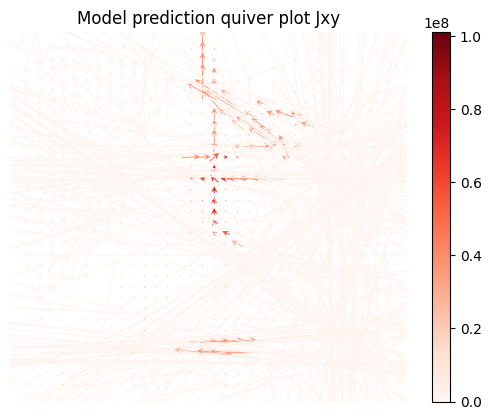

In [29]:
def quiver(predImage, magPredImage, step, noiseMax):
    # Only taking every {step} value from the data
    sPredData = predImage[::step, ::step]
    sMagPredImage = magPredImage[::step, ::step]

    # Removing very low signal background noise
    Jxs = np.where(np.abs(sMagPredImage) < noiseMax, 0, sPredData[:, :, 0])
    Jys = np.where(np.abs(sMagPredImage) < noiseMax, 0, sPredData[:, :, 1])

    # Creating a meshgrid for the arrows to sit on
    x, y = np.arange(predImage.shape[0]), np.arange(predImage.shape[1])
    X, Y = np.meshgrid(x, y)
    
    xs, ys = X[::step, ::step], Y[::step, ::step]

    # Normalising xs, ys so that arrows are the same size and removing values
    # under the noiseMax
    xsNorm = np.where(sMagPredImage > noiseMax, Jxs / sMagPredImage, Jxs)
    ysNorm = np.where(sMagPredImage > noiseMax, Jys / sMagPredImage, Jys)


    absMax = np.max(np.abs(predImage))
    plt.quiver(xs, ys, xsNorm, ysNorm,
               sMagPredImage,
               cmap="Reds",
               scale=25,
               angles='xy',
               pivot='mid',
               headwidth=7,
               headlength=7)
    plt.gca().invert_yaxis()
    plt.clim(0, absMax)
    plt.axis("off")
    plt.colorbar()
    plt.title("Model prediction quiver plot Jxy")
    plt.show()

quiver(predData[0], magPredImage, 2, 0.8)

### Steamline plot

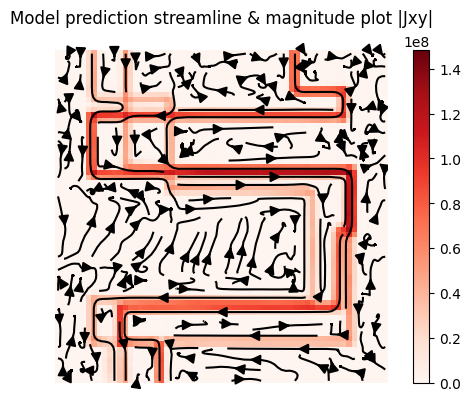

In [18]:
def streamline(predImage, magPredImage, noiseMax):
    x = np.arange(magPredImage.shape[0])
    y = np.arange(magPredImage.shape[1])

    xs, ys = predImage[:, :, 0], predImage[:, :, 1]
    xsNorm = np.where(np.abs(xs) < noiseMax, 0, xs)
    ysNorm = np.where(np.abs(ys) < noiseMax, 0, ys)
    # magPredImage = np.where(np.abs(magPredImage) < noiseMax, 0, magPredImage)

    absMax = np.max(np.abs(predImage))
    magMax = np.max(np.abs(magPredImage))

    plt.imshow(magPredImage, norm="linear",
            vmin=0, vmax=magMax)

    plt.streamplot(x, y, xsNorm, ysNorm,
                color="black",
                linewidth=1.5,
                density=1,
                arrowsize=1.5,
                minlength=0.1,
                maxlength=4,
                broken_streamlines=True)
    
    # plt.gca().invert_yaxis()
    plt.clim(0, absMax)
    plt.axis("off")
    plt.set_cmap("Reds")
    plt.colorbar(shrink=0.9)
    plt.title("Model prediction streamline & magnitude plot |Jxy|")
    plt.show()

streamline(predData[0], magPredImage, 0.8)

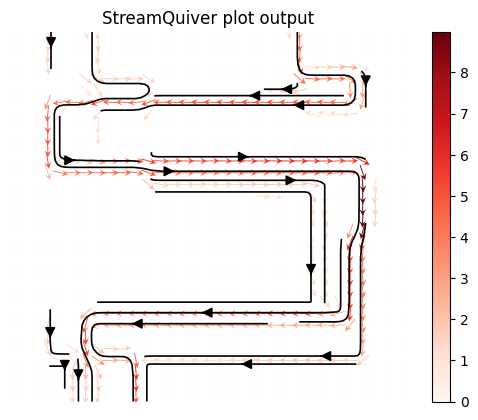

In [ ]:
def streamquiver(predImage, magPredImage, step, noiseMax):
    # Only taking every {step} value from the data
    sPredData = predImage[::step, ::step]
    sMagPredImage = magPredImage[::step, ::step]

    # Removing very low signal background noise
    Jxs = np.where(np.abs(sMagPredImage) < noiseMax, 0, sPredData[:, :, 0])
    Jys = np.where(np.abs(sMagPredImage) < noiseMax, 0, sPredData[:, :, 1])

    # Creating a meshgrid for the arrows to sit on
    x, y = np.arange(predImage.shape[0]), np.arange(predImage.shape[1])
    X, Y = np.meshgrid(x, y)
    
    xs, ys = X[::step, ::step], Y[::step, ::step]

    # Normalising xs, ys so that arrows are the same size and removing values
    # under the noiseMax
    JxsNorm = np.where(sMagPredImage > noiseMax, Jxs / sMagPredImage, Jxs)
    JysNorm = np.where(sMagPredImage > noiseMax, Jys / sMagPredImage, Jys)


    absMax = np.max(np.abs(predImage))
    plt.quiver(xs, ys, JxsNorm, JysNorm,
               sMagPredImage,
               cmap="Reds",
               scale=25,
               angles='xy',
               pivot='mid',
               headwidth=7,
               headlength=7)
    
    x = np.arange(magPredImage.shape[0])
    y = np.arange(magPredImage.shape[1])

    xs, ys = predImage[:, :, 0], predImage[:, :, 1]
    xsNorm = np.where(np.abs(xs) < noiseMax, 0, xs)
    ysNorm = np.where(np.abs(ys) < noiseMax, 0, ys)
    # magPredImage = np.where(np.abs(magPredImage) < noiseMax, 0, magPredImage)

    plt.streamplot(x, y, xsNorm, ysNorm,
                color="black",
                linewidth=1.2,
                density=1,
                arrowsize=1.5)

    plt.gca().invert_yaxis()
    plt.clim(0, absMax)
    plt.axis("off")
    plt.colorbar()
    plt.title("StreamQuiver plot output")
    plt.show()

streamquiver(predData[0], magPredImage, 2, 1)

### Divergence Plot

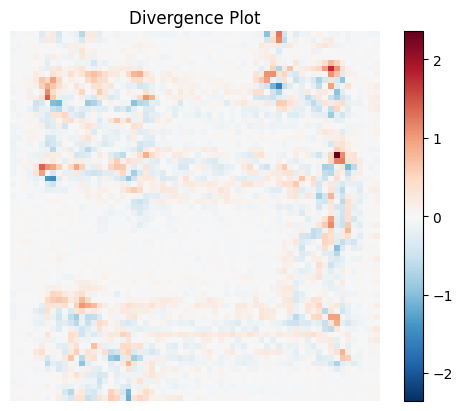

In [99]:

def divergence(predImage):
    djx_dx = np.gradient(predImage[:,:,0], axis=1)
    djy_dy = np.gradient(predImage[:,:,1], axis=0)
    divergence = djx_dx + djy_dy
    divMax = np.max(np.abs(divergence))

    plt.imshow(divergence, norm="linear", cmap="RdBu_r")
    plt.clim(-divMax, divMax)
    plt.axis("off")
    plt.colorbar()
    plt.title("Divergence Plot")
    plt.show()
divergence(predData[0])

## Image 2

/tmp/ipykernel_541898/32903851.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  SQUIDInputData = np.array(SQUIDify(rawInData, 62, 0)).swapaxes(1,3)
/tmp/ipykernel_541898/32903851.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  noise = np.array(torch.normal(mean=normInData.mean(), std=noise, size=np.shape(normInData)))


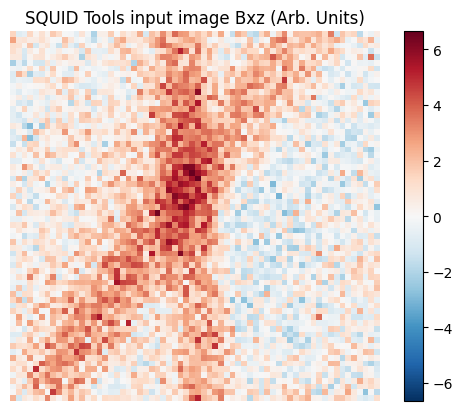

In [19]:
normInputImage, normInData, rawInData = inputImage(6, 800, 1, filename="/data/s4451856/training_data/64x64_50um_Bxyz_006.npy")

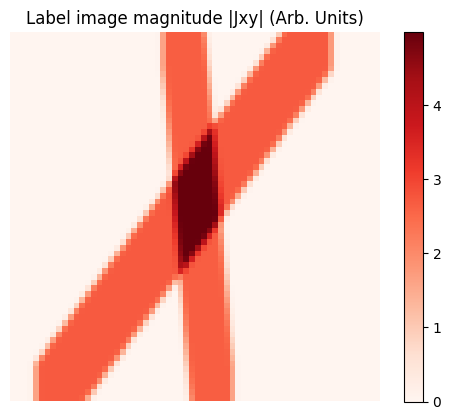

In [20]:
normOutImage = labelImage(6, 800)

In [73]:
predData = predict(normInData)

In [21]:
predData = UNET_normalized_inference(rawInData.swapaxes(1,3), model)

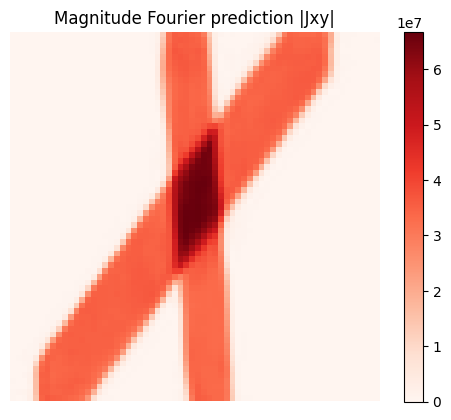

In [22]:
magPredImage = magnitude(predData[800])
magImage(magPredImage)

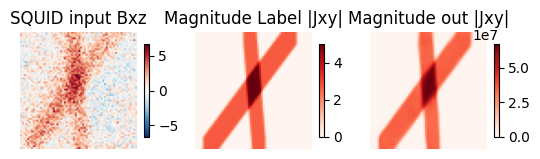

In [23]:
inputLabelMagCompImage(normInputImage, normOutImage, magPredImage)

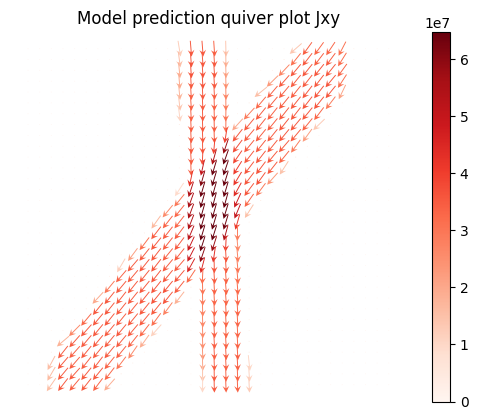

In [31]:
quiver(predData[800], magPredImage, 2, 1e7*0.8)

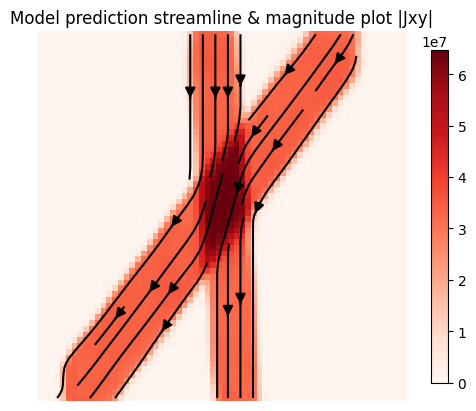

In [28]:
streamline(predData[800], magPredImage, 1e7*0.8)

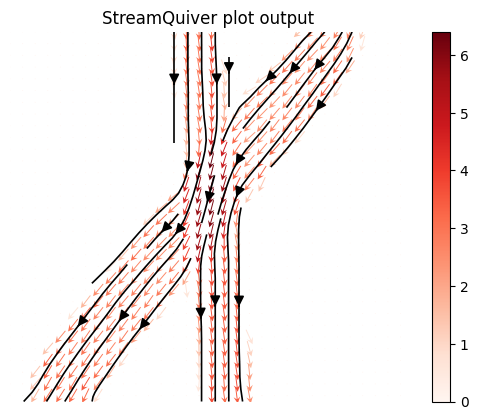

In [107]:
streamquiver(predData[800], magPredImage, 2, 0.5)

## Image 3

/tmp/ipykernel_3328663/2608737529.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  noise = np.array(torch.normal(mean=normInData.mean(), std=noise, size=np.shape(normInData)))


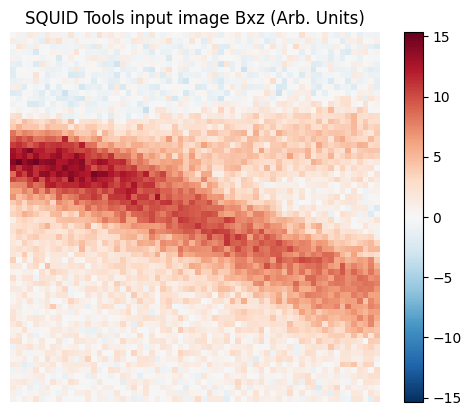

In [156]:
normInputImage, normInData, rawInData = inputImage(50, 100, 1)#, filename="/data/s4451856/training_data/64x64_50um_Bxyz_050.npy")

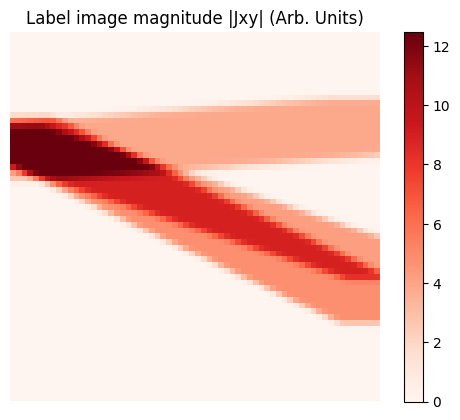

In [79]:
normOutImage = labelImage(50, 100)

In [84]:
predData = predict(normInData)

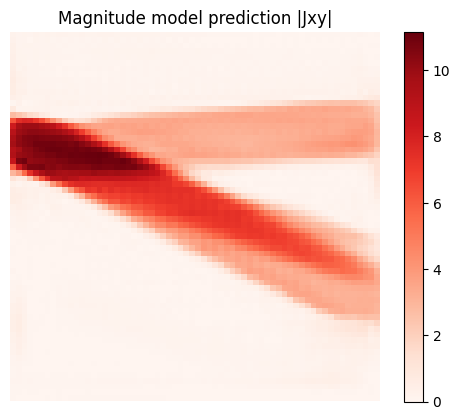

In [85]:
magPredImage = magnitude(predData[100])
magImage(magPredImage)

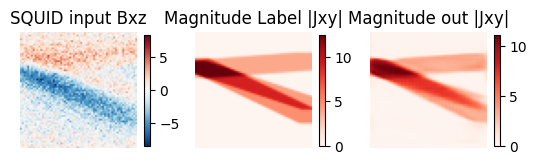

In [86]:
inputLabelMagCompImage(normInputImage, normOutImage, magPredImage)

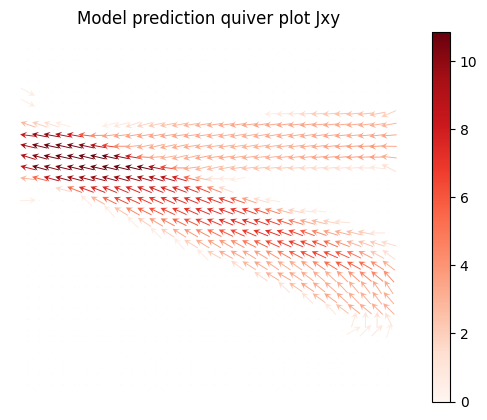

In [87]:
quiver(predData[100], magPredImage, 2, 0.5)

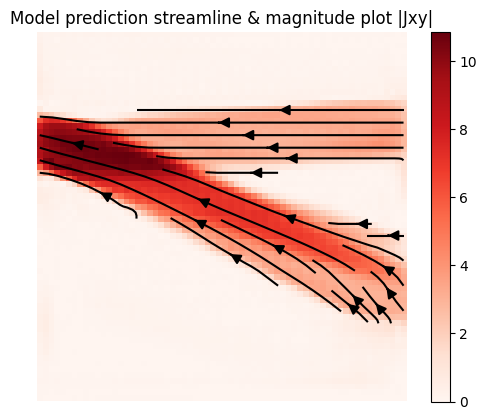

In [88]:
streamline(predData[100], magPredImage, 1)

# Validation Data

/tmp/ipykernel_1324305/2703497000.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  SQUIDInputData = np.array(SQUIDify(rawInData, 62, 0)).swapaxes(1,3)
/tmp/ipykernel_1324305/2703497000.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  noise = np.array(torch.normal(mean=normInData.mean(), std=noise, size=np.shape(normInData)))


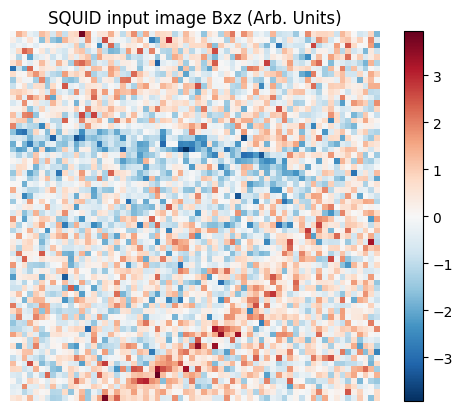

In [115]:
normInputImage, normInData, rawInData = inputImage(0, 0, 1, filename="../MAGIC_UNET/Data/InDistributionVal/validation_64x64_50um_Bxyz.npy")

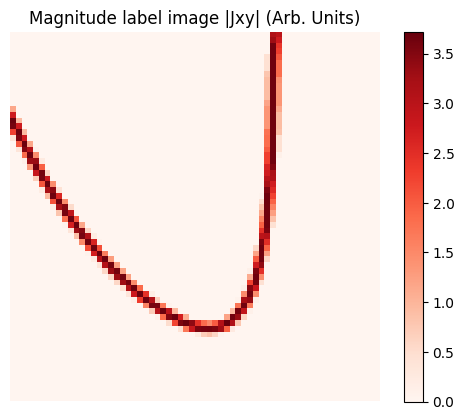

In [116]:
magOutImage = labelImage(0, 0, filename="../MAGIC_UNET/Data/InDistributionVal/validation_64x64_50um_Jxy.npy")

In [117]:
predData = predict(normInData)

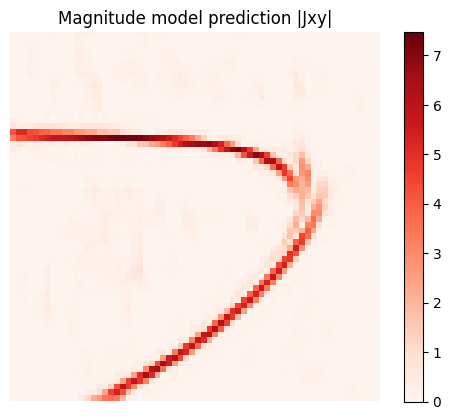

In [118]:
magPredImage = magnitude(predData[0])
magImage(magPredImage)

# Real SQUID Data
## Kagome

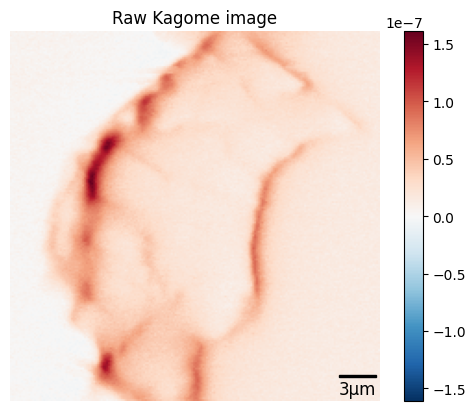

In [29]:
ascKagome = np.loadtxt("../qual_test_set/kagome.asc").reshape([200, 200])
fontprops = fm.FontProperties(size=12)

magMax = np.max(np.abs(ascKagome))
fig, ax = plt.subplots()
img = ax.imshow(ascKagome, norm="linear", cmap="RdBu_r",
           vmin=-magMax, vmax=magMax)
ax.axis("off")
fig.colorbar(img, ax=ax)
plt.title("Raw Kagome image")

scalebar = AnchoredSizeBar(ax.transData,
                                20, '3μm', 'lower right',
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=1,
                                fontproperties=fontprops)
ax.add_artist(scalebar)
plt.show()

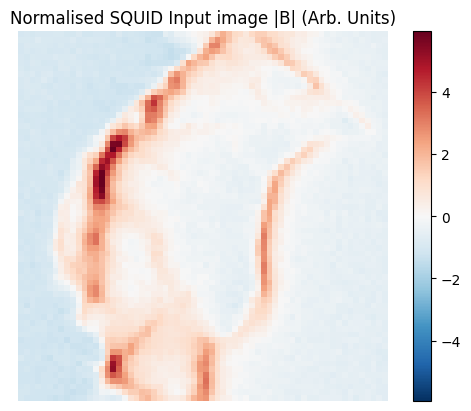

In [95]:
kagome = cv2.resize(ascKagome, dsize=(64, 64), interpolation=cv2.INTER_LINEAR).reshape([64, 64, 1])

kagomeNorm = (kagome - kagome.mean()) / kagome.std()

magMax = np.max(np.abs(kagomeNorm))
plt.imshow(kagomeNorm, norm="linear", cmap="RdBu_r",
           vmin=-magMax, vmax=magMax)
plt.axis("off")
plt.colorbar()
plt.title("Normalised SQUID Input image |B| (Arb. Units)")
plt.show()

In [98]:
print("Top Magnitude:", np.sum(kagomeNorm[0]))
print("Bottom Magnitude:", np.sum(kagomeNorm[-1]))

Top Magnitude: 2.984279490192421e-13
Bottom Magnitude: 2.984279490192421e-13


In [99]:
kagomeNorm = kagomeNorm.reshape([1, 64, 64, 1])
#kagomeNorm = np.flip(kagomeNorm.swapaxes(1, 2), axis=2)
kagomeTensor = torch.from_numpy(kagomeNorm.swapaxes(1,3).astype('float32'))

with torch.inference_mode():
    kagomePred = model(kagomeTensor)
    kagomePred = kagomePred.detach().numpy().swapaxes(1,3)
    #kagomePred = np.flip(kagomePred, axis=2).swapaxes(1, 2)

### Magnitude

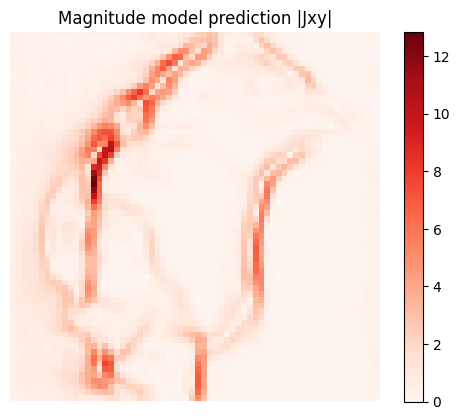

In [100]:
# predData = predData.reshape([64,64,1])
magKagomePred = magnitude(kagomePred[0])
magImage(magKagomePred)

### Calculate magnitude at top & bottom

In [101]:
print("Top Magnitude:", np.sum(magKagomePred[0]))
print("Bottom Magnitude:", np.sum(magKagomePred[-1]))

Top Magnitude: 37.222326134091425
Bottom Magnitude: 35.710092484505914


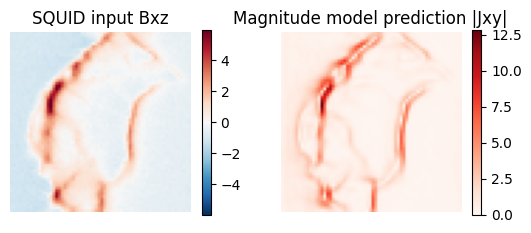

In [102]:
def inputMagCompImage(inputImage, magPredImage):
    plt.subplot(1, 2, 1)
    inMax = np.max(np.abs(inputImage))
    plt.imshow(inputImage, norm="linear", cmap="RdBu_r",
            vmin=-inMax, vmax=inMax)
    plt.colorbar(shrink=0.5)
    plt.axis("off")
    plt.title("SQUID input Bxz")

    plt.subplot(1, 2, 2)
    predMax = np.max(np.abs(magPredImage))
    plt.imshow(magPredImage, norm="linear", cmap="Reds",
            vmin=0, vmax=predMax)
    plt.axis("off")
    plt.colorbar(shrink=0.5)
    plt.title("Magnitude model prediction |Jxy|")
    plt.show()

inputMagCompImage(kagomeNorm[0], magKagomePred)

### Quiver Plot

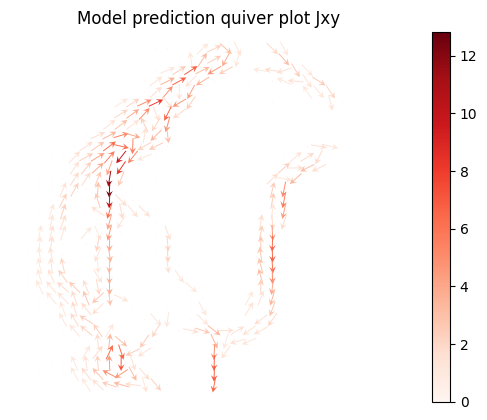

In [104]:
quiver(kagomePred[0], magKagomePred, 2, 1)

### Streamline Plot

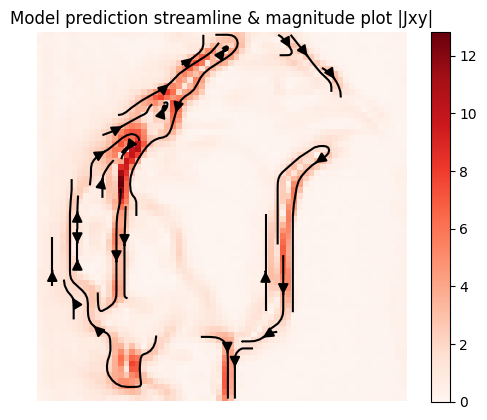

In [105]:
streamline(kagomePred[0], magKagomePred, 1)

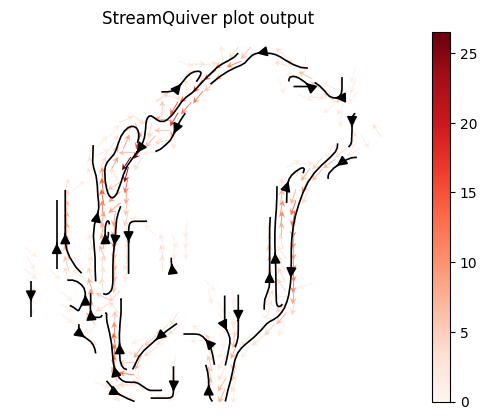

In [128]:
streamquiver(kagomePred[0], magKagomePred, 2, 1)

### Divergence

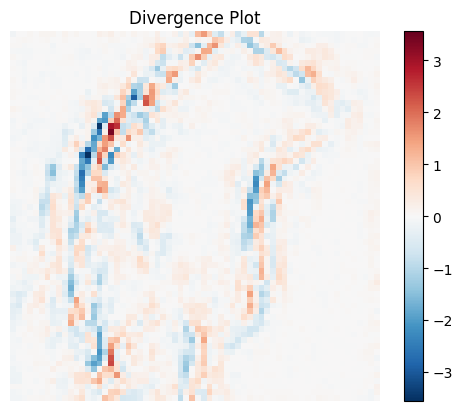

In [129]:
divergence(kagomePred[0])

## Serpentine

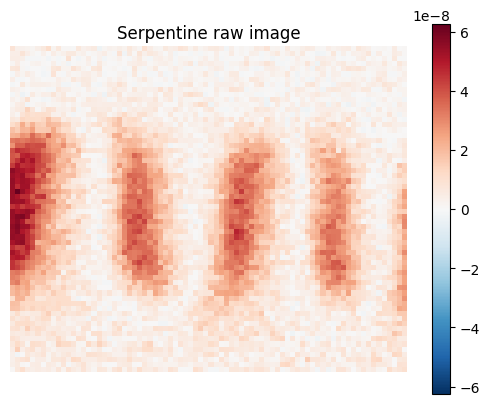

In [106]:
ascSerpentine = np.loadtxt("../qual_test_set/serpentine.asc").reshape([64, 78])

magMax = np.max(np.abs(ascSerpentine))
plt.imshow(ascSerpentine, norm="linear", cmap="RdBu_r",
                    vmin=-magMax, vmax=magMax)
plt.axis("off")
plt.colorbar()
plt.title("Serpentine raw image")
plt.show()

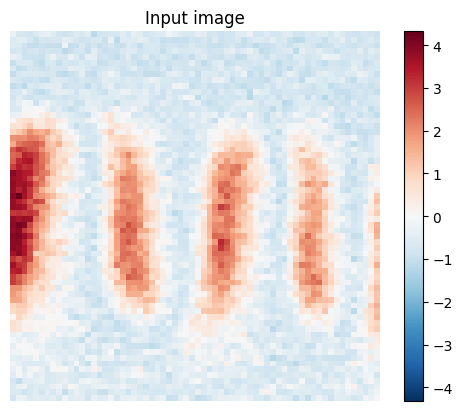

In [107]:
serpentine = cv2.resize(ascSerpentine, dsize=(64, 64), interpolation=cv2.INTER_LINEAR).reshape([64, 64, 1])

serpentineNorm = (serpentine - serpentine.mean()) / serpentine.std()

magMax = np.max(np.abs(serpentineNorm))
plt.imshow(serpentineNorm, norm="linear", cmap="RdBu_r",
                    vmin=-magMax, vmax=magMax)
plt.axis("off")
plt.colorbar()
plt.title("Input image")
plt.show()

In [108]:
serpentineNorm = serpentineNorm.reshape([1, 64, 64, 1])
#serpentineNorm = np.flip(serpentineNorm.swapaxes(1, 2), axis=2)
serpentineTensor = torch.from_numpy(serpentineNorm.swapaxes(1,3).astype('float32'))

with torch.inference_mode():
    serpPred = model(serpentineTensor)
    serpPred = serpPred.detach().numpy().swapaxes(1,3)
    #serpPred = np.flip(serpPred, axis=2).swapaxes(1, 2)

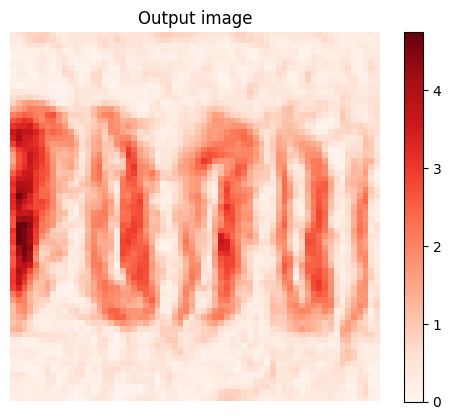

In [109]:
magSerpPred = magnitude(serpPred[0])

magMax = np.max(np.abs(magSerpPred))
plt.imshow(magSerpPred, norm="linear", cmap="Reds",
                    vmin=0, vmax=magMax)
plt.axis("off")
plt.colorbar()
plt.title("Output image")
plt.show()

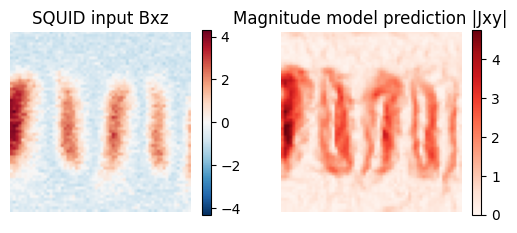

In [110]:
inputMagCompImage(serpentineNorm[0], magSerpPred)

### Quiver

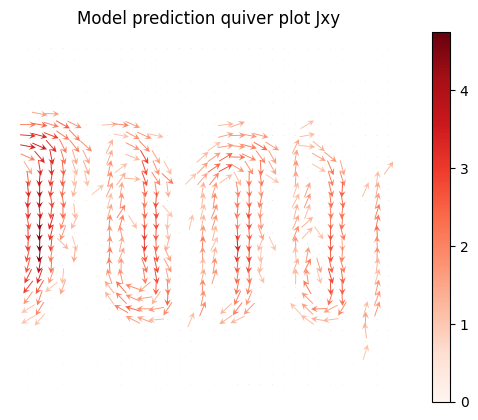

In [113]:
quiver(serpPred[0], magSerpPred, 2, 1)

### Streamline

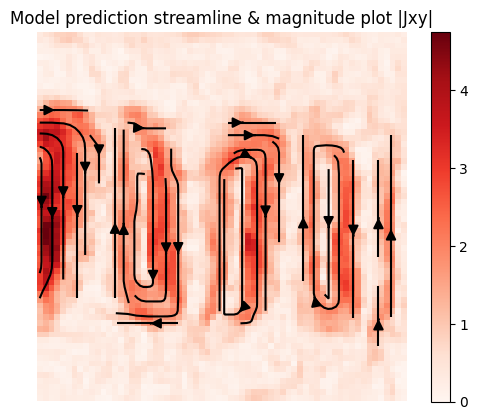

In [115]:
streamline(serpPred[0], magSerpPred, 1)

## Zigzag

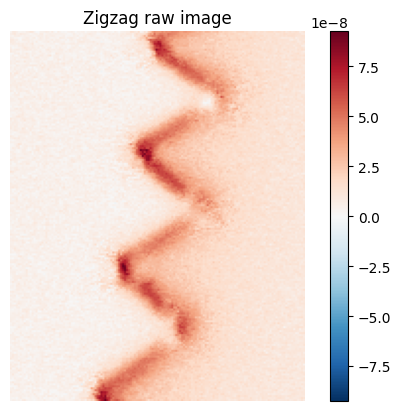

In [116]:
ascZigzag = np.loadtxt("../qual_test_set/zigzag.asc").reshape([188, 150])

magMax = np.max(np.abs(ascZigzag))
plt.imshow(ascZigzag, norm="linear", cmap="RdBu_r",
                    vmin=-magMax, vmax=magMax)
plt.axis("off")
plt.colorbar()
plt.title("Zigzag raw image")
plt.show()

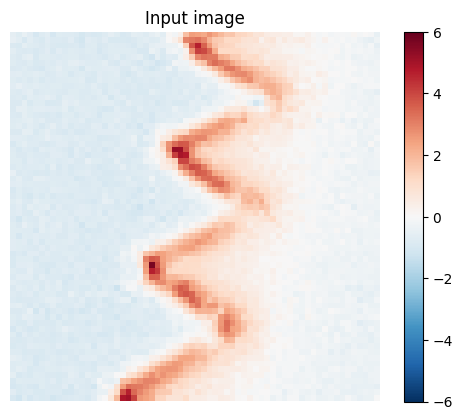

In [117]:
zigzag = cv2.resize(ascZigzag, dsize=(64, 64), interpolation=cv2.INTER_LINEAR).reshape([64, 64, 1])

zigzagNorm = (zigzag - zigzag.mean()) / zigzag.std()

plt.imshow(zigzagNorm, norm="linear", cmap="RdBu_r",
                    vmin=-6, vmax=6)
plt.axis("off")
plt.colorbar()
plt.title("Input image")
plt.show()

In [118]:
zigzagNorm = zigzagNorm.reshape([1, 64, 64, 1])
#zigzagNorm = np.flip(zigzagNorm.swapaxes(1, 2), axis=2)
zigzagTensor = torch.from_numpy(zigzagNorm.swapaxes(1,3).astype('float32'))

with torch.inference_mode():
    zigPred = model(zigzagTensor)
    zigPred = zigPred.detach().numpy().swapaxes(1,3)
    #zigPred = np.flip(zigPred, axis=2).swapaxes(1, 2)

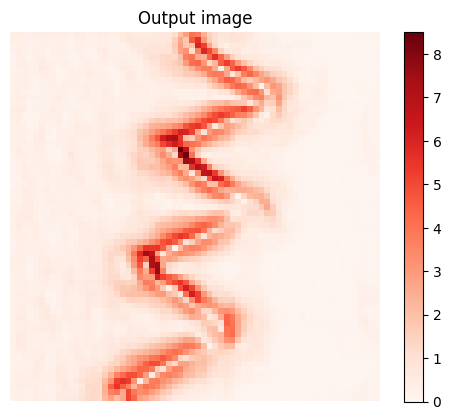

In [119]:
magZZPred = magnitude(zigPred[0])
magMax = np.max(np.abs(magZZPred))
plt.imshow(magZZPred, norm="linear", cmap="Reds",
                    vmin=0, vmax=magMax)
plt.axis("off")
plt.colorbar()
plt.title("Output image")
plt.show()

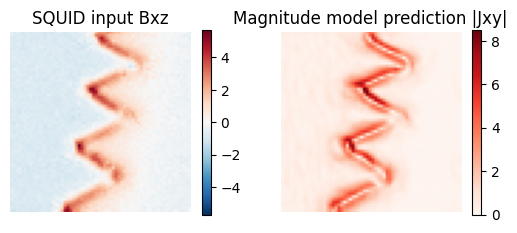

In [121]:
inputMagCompImage(zigzagNorm[0], magZZPred)

### Quiver

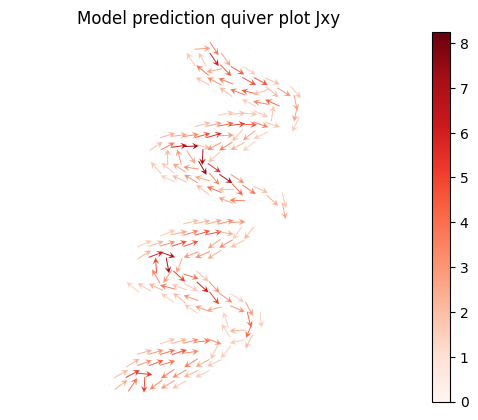

In [120]:
quiver(zigPred[0], magZZPred, 2, 1.5)

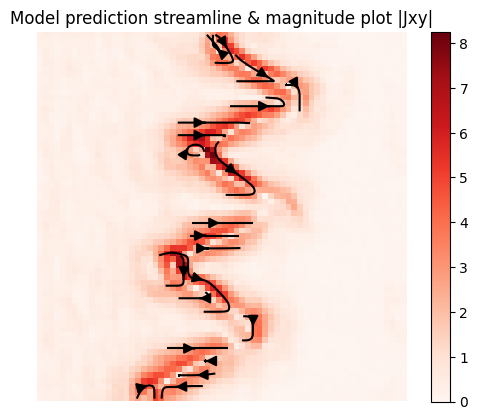

In [123]:
streamline(zigPred[0], magZZPred, 2)

## Serpentine Metropolis

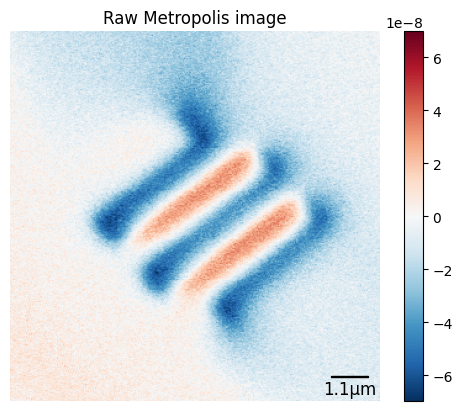

In [ ]:
ascMetro = np.loadtxt("../qual_test_set/metropolis.asc").reshape([300, 300])
fontprops = fm.FontProperties(size=12)

magMax = np.max(np.abs(ascMetro))
fig, ax = plt.subplots()
img = ax.imshow(ascMetro, norm="linear", cmap="RdBu_r",
                    vmin=-magMax, vmax=magMax)
ax.axis("off")
fig.colorbar(img, ax=ax)
plt.title("Raw Metropolis image")

scalebar = AnchoredSizeBar(ax.transData,
                            30, '1.1μm', 'lower right',
                            pad=0.1,
                            color='black',
                            frameon=False,
                            size_vertical=1,
                            fontproperties=fontprops)
ax.add_artist(scalebar)
plt.show()

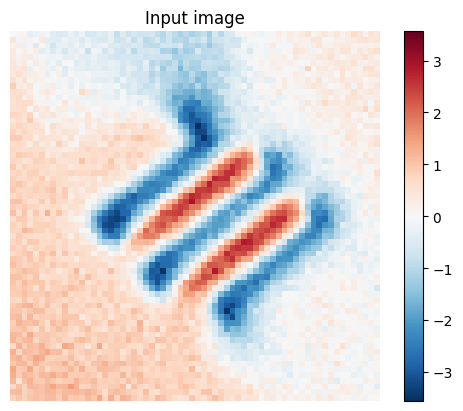

In [125]:
metro = cv2.resize(ascMetro, dsize=(64, 64), interpolation=cv2.INTER_LINEAR).reshape([64, 64, 1])

metroNorm = (metro - metro.mean()) / metro.std()

magMax = np.max(np.abs(metroNorm))
plt.imshow(metroNorm, norm="linear", cmap="RdBu_r",
                    vmin=-magMax, vmax=magMax)
plt.axis("off")
plt.colorbar()
plt.title("Input image")
plt.show()

In [126]:
metroNorm = metroNorm.reshape([1, 64, 64, 1])
#metroNorm = np.flip(metroNorm.swapaxes(1, 2), axis=2)
metroTensor = torch.from_numpy(metroNorm.swapaxes(1,3).astype('float32'))

with torch.inference_mode():
    metPred = model(metroTensor)
    metPred = metPred.detach().numpy().swapaxes(1,3)
    #metPred = np.flip(metPred, axis=2).swapaxes(1, 2)

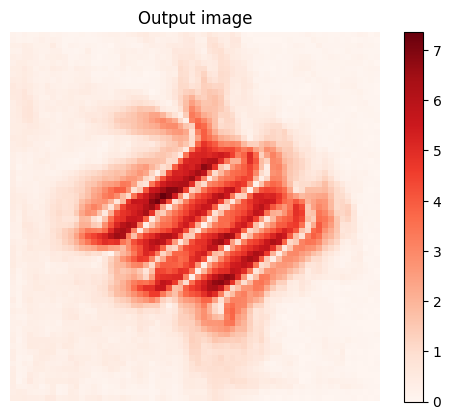

In [127]:
magMetPred = magnitude(metPred[0])
magMax = np.max(np.abs(magMetPred))
plt.imshow(magMetPred, norm="linear", cmap="Reds",
                    vmin=0, vmax=magMax)
plt.axis("off")
plt.colorbar()
plt.title("Output image")
plt.show()

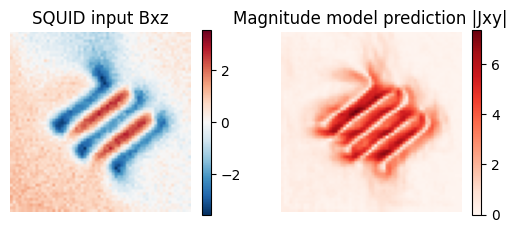

In [128]:
inputMagCompImage(metroNorm[0], magMetPred)

### Quiver

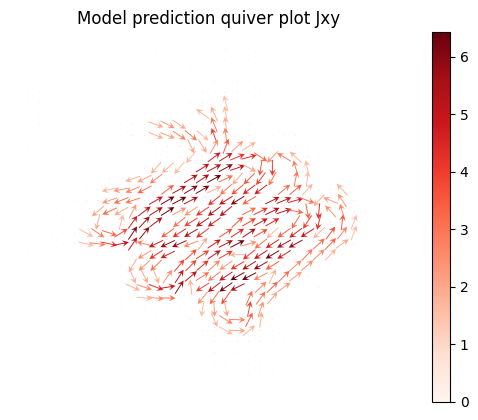

In [132]:
quiver(metPred[0], magMetPred, 2, 1.5)

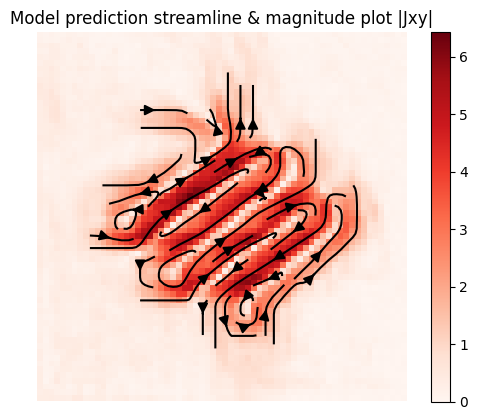

In [135]:
streamline(metPred[0], magMetPred, 1)